1. Manejo de histograma: la imagen ‘chairs oscura.jpg’ posee poca luminosi-
dad. Usted debe mejorar la imagen a partir de la ecualizaci ́on de histograma,
comparando los efectos de realizarla en RGB (por planos), en HSV (canal V) y
en HSI (canal I).
- Visualice la imagen original ‘chairs.jpg’, comparela con las im ́agenes re-
alzadas y discuta los resultados.
- Repita el proceso para otras im ́agenes de bajo contraste (por ejemplo
‘flowers oscura.tif’) y analice los resultados.
2. Realce mediante acentuado: utilice la imagen ‘camino.tif’ que se observa de-
senfocada. Usted debe mejorar la imagen aplicando un filtro pasa altos de suma 1. Compare los resultados de procesar la imagen en los modelos RGB, HSV y HSI.


In [89]:
# Configuración Inicial e Importaciones
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets


In [90]:

    
def comparar_rgb_horizontal(img1, img2, titulo1="Original", titulo2="Procesada"):
    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    
    axs[0].imshow(img1)
    axs[0].set_title(titulo1)
    axs[0].axis("off")
    
    axs[1].imshow(img2)
    axs[1].set_title(titulo2)
    axs[1].axis("off")
    
    plt.tight_layout()
    plt.show()

def interact_realce(img):

    def probar(a):

        centro = 1 + 4*a

        mask = np.array([
            [0,  -a, 0],
            [-a, centro, -a],
            [0,  -a, 0]
        ], dtype=np.float32)

        print("Máscara:")
        print(mask)
        print("Suma:", mask.sum())

        img_f = cv2.filter2D(img.astype(np.float32), -1, mask) #puede retornar negativos
        img_f = np.clip(img_f, 0, 255).astype(np.uint8)

        fig, axs = plt.subplots(1, 2, figsize=(10,5))

        axs[0].imshow(img)
        axs[0].set_title("Original")
        axs[0].axis("off")

        axs[1].imshow(img_f)
        axs[1].set_title(f"Realce a={a:.2f}")
        axs[1].axis("off")

        plt.tight_layout()
        plt.show()
        
    interact(
        probar,
        a=FloatSlider(min=0, max=2, step=0.05, value=0.5)
    )

# Parte 1

In [91]:
img = cv2.imread('../Imagenes_cursado/chairs_oscura.jpg')
img_original = cv2.imread('../Imagenes_cursado/chairs.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


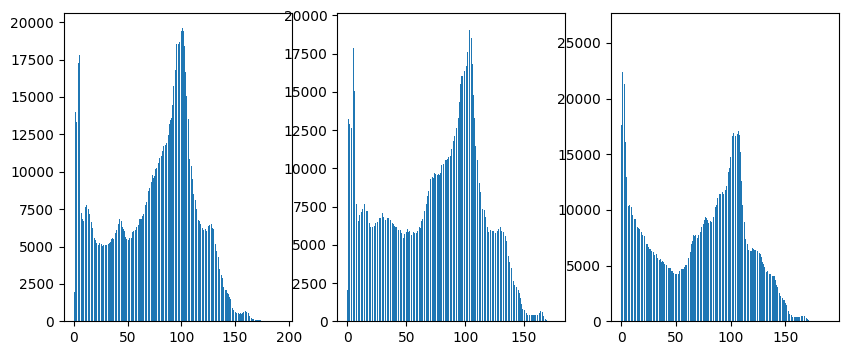

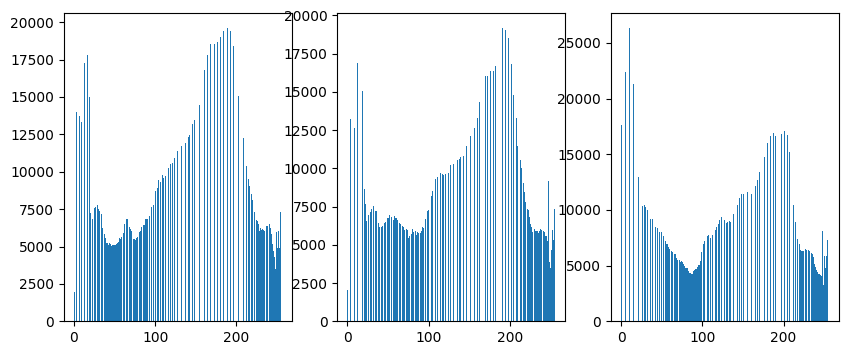

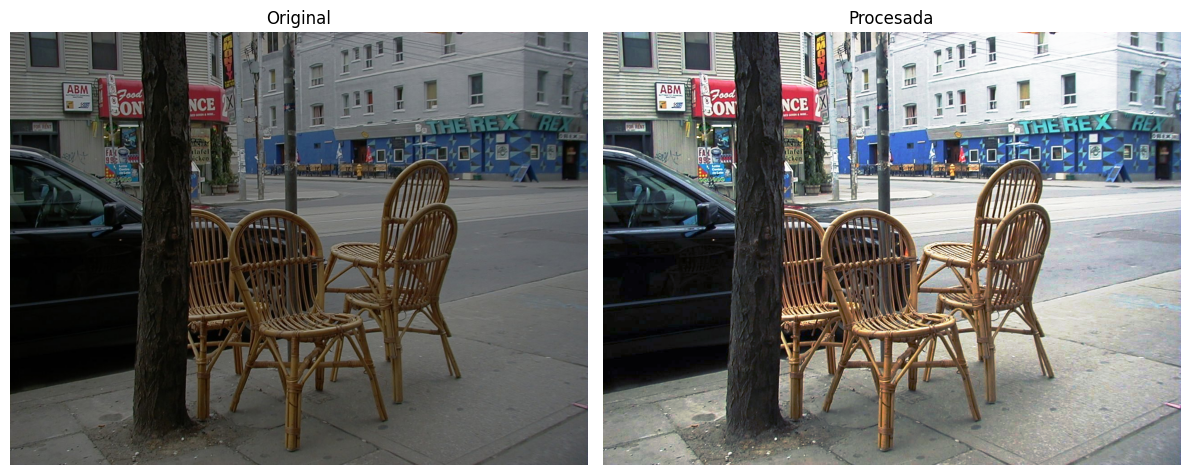

In [92]:
# Resolución para RGB
R, G, B = cv2.split(img_rgb)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].hist(np.ravel(R), bins = 255)
axes[1].hist(np.ravel(G),bins = 255)
axes[2].hist(np.ravel(B),bins = 255)
plt.show()

R_eq = cv2.equalizeHist(R)
G_eq = cv2.equalizeHist(G)
B_eq = cv2.equalizeHist(B)

img_rgb_eq = cv2.merge([R_eq, G_eq, B_eq])

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].hist(np.ravel(R_eq), bins = 255)
axes[1].hist(np.ravel(G_eq),bins = 255)
axes[2].hist(np.ravel(B_eq),bins = 255)
plt.show()


comparar_rgb_horizontal(img_rgb, img_rgb_eq)



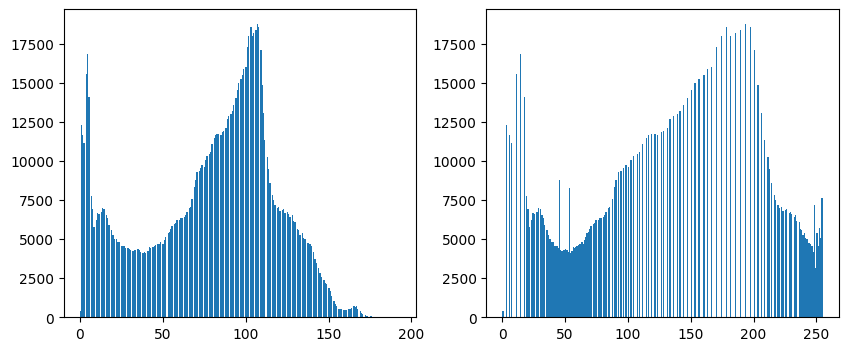

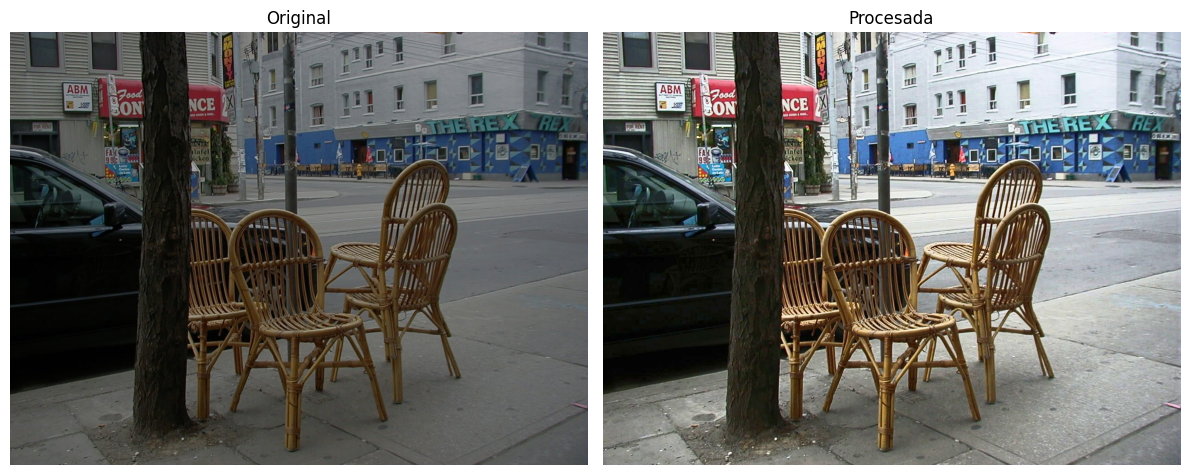

In [93]:
# para el caso de hsv tengo que ecualizar v nomas
H, S, V = cv2.split(img_hsv)

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].hist(np.ravel(V), bins = 255)

V_eq = cv2.equalizeHist(V)
axs[1].hist(np.ravel(V_eq), bins = 255)
plt.show()


img_eq_hsv = cv2.merge([H,S,V_eq])
rgb_hsveq = cv2.cvtColor(img_eq_hsv, cv2.COLOR_HSV2RGB)

comparar_rgb_horizontal(img_rgb, rgb_hsveq)



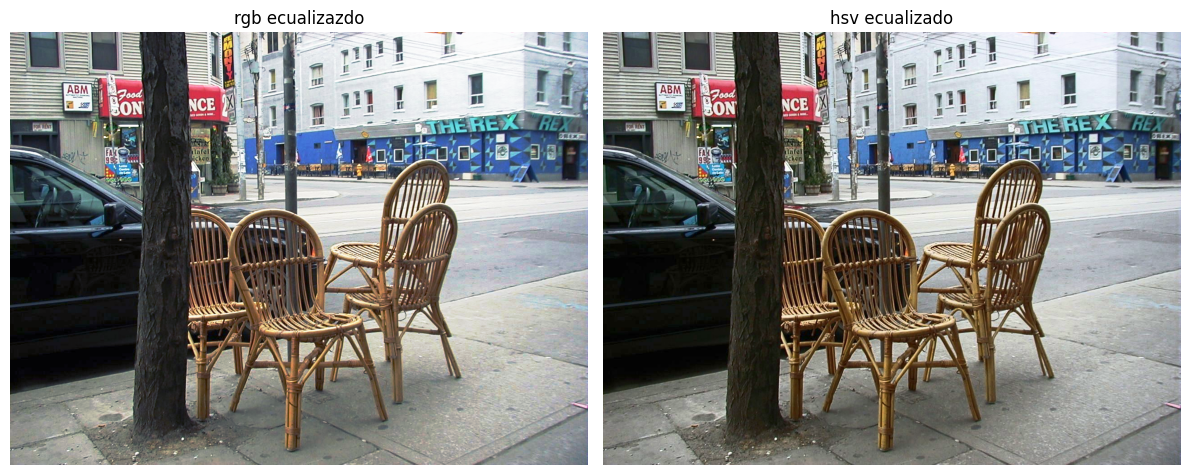

In [94]:
comparar_rgb_horizontal(img_rgb_eq, rgb_hsveq, "rgb ecualizazdo", "hsv ecualizado")


# parte 2

## RGB

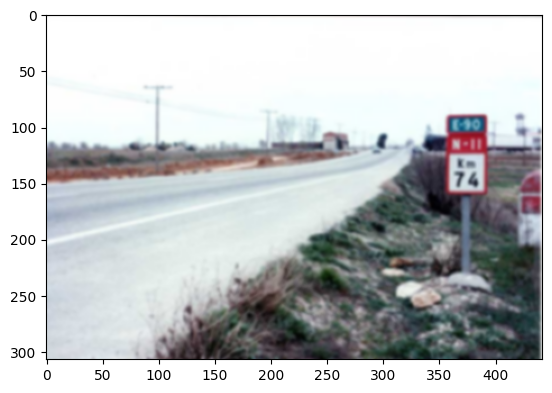

In [95]:
img = cv2.imread("../Imagenes_cursado/camino.tif")

camino_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(camino_rgb)
plt.show()


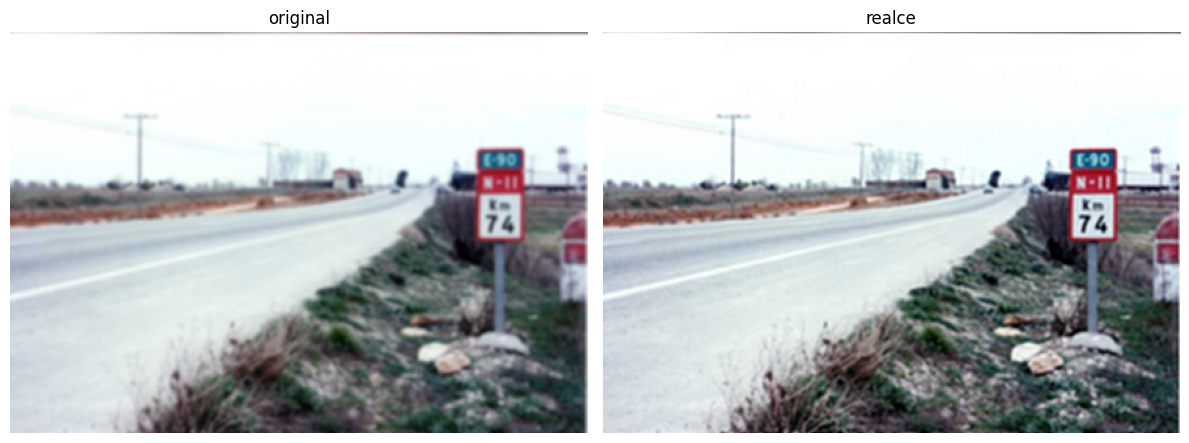

In [96]:
# definimos una matriz de filtro pasa altos CASO RGB

mask = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0,-1,0]
])

R, G, B = cv2.split(camino_rgb)

R_pa = cv2.filter2D(R,-1,mask)
G_pa = cv2.filter2D(G,-1,mask)
B_pa = cv2.filter2D(B,-1,mask)

RGB_pa = cv2.merge([R_pa, G_pa, B_pa])



comparar_rgb_horizontal(camino_rgb, RGB_pa, "original", "realce")


## HSV

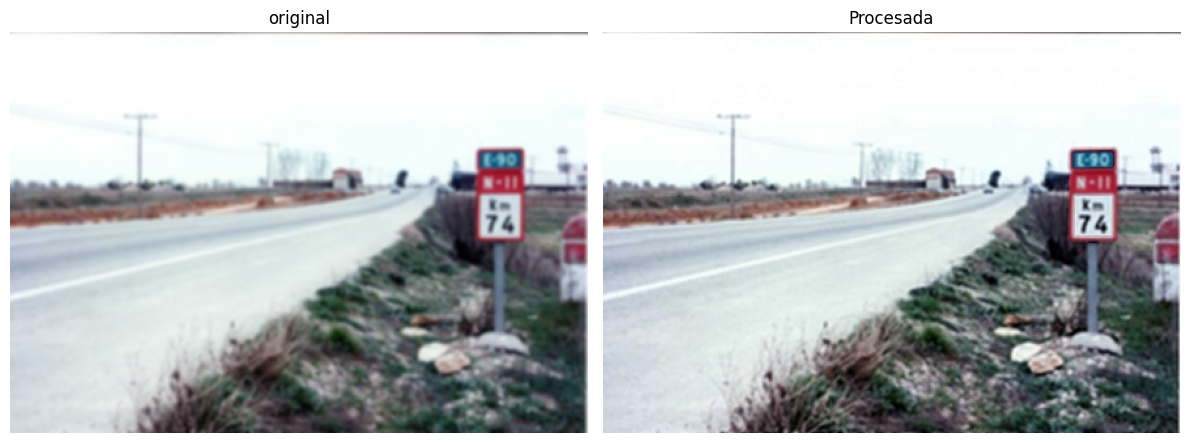

In [98]:
# para una foto HSV
img_HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

H, S, V = cv2.split(img_HSV)

V_pa = cv2.filter2D(V, -1, mask)

hsv_eq = cv2.merge([H,S, V_pa])

#rgb_hsv = cv2.cvtColor(img_HSV, cv2.COLOR_HSV2RGB)
rgb_hsv_eq = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB)

comparar_rgb_horizontal(camino_rgb, rgb_hsv_eq, "original")

